In [61]:
print('hello')

hello


In [62]:
! pip install nltk

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# worldcloud
import random
from wordcloud import WordCloud


In [64]:
# Download NLTK resources (only needed once)
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [65]:
# retrieving the datasets we used for the last notebook

raw_path = '../data/olist_datasets/'

df_customer = pd.read_csv(raw_path + 'olist_customers_dataset.csv')
df_geolocation = pd.read_csv(raw_path + 'olist_geolocation_dataset.csv')
df_orders = pd.read_csv(raw_path + 'olist_orders_dataset.csv')
df_order_items = pd.read_csv(raw_path + 'olist_order_items_dataset.csv')
df_order_payments = pd.read_csv(raw_path + 'olist_order_payments_dataset.csv')
df_order_reviews = pd.read_csv(raw_path + 'olist_order_reviews_dataset.csv')
df_products = pd.read_csv(raw_path + 'olist_products_dataset.csv')
df_sellers = pd.read_csv(raw_path + 'olist_sellers_dataset.csv')


# I - Sentiment analysis of customer reviews

## A - Reminders on the Review dataframe

In [66]:
# checking that df_order_reviews is loaded

# Load the dataset from the path shown in your file explorer
df_order_reviews = pd.read_csv(raw_path + 'olist_order_reviews_dataset.csv')

# Now you can check the first 10 rows
df_order_reviews.head(10)



,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
5,15197aa66ff4d0650b5434f1b46cda19,b18dcdf73be66366873cd26c5724d1dc,1,NaN,NaN,2018-04-13 00:00:00,2018-04-16 00:39:37
6,07f9bee5d1b850860defd761afa7ff16,e48aa0d2dcec3a2e87348811bcfdf22b,5,NaN,NaN,2017-07-16 00:00:00,2017-07-18 19:30:34
7,7c6400515c67679fbee952a7525281ef,c31a859e34e3adac22f376954e19b39d,5,NaN,NaN,2018-08-14 00:00:00,2018-08-14 21:36:06
8,a3f6f7f6f433de0aefbb97da197c554c,9c214ac970e84273583ab523dfafd09b,5,NaN,NaN,2017-05-17 00:00:00,2017-05-18 12:05:37
9,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,4,recomendo,aparelho eficiente. no site a marca do aparelh...,2018-05-22 00:00:00,2018-05-23 16:45:47


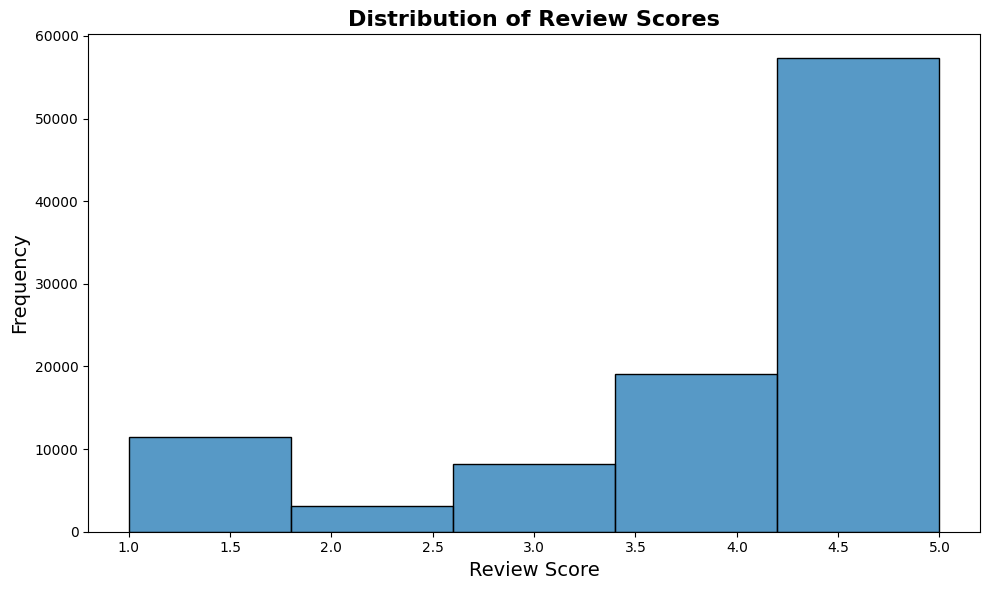

In [67]:
# Create a distribution plot (dist plot) with seaborn on the review score

# "professional" colors
colors = ['#2C3E50', '#E74C3C', '#ECF0F1', '#3498DB', '#2ECC71', '#F1C40F', '#9B59B6']

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Create histogram with seaborn
ax = sns.histplot(data=df_order_reviews, 
            x='review_score',
            bins=5,
            edgecolor='black',
            stat='count')

# Customizing the plot
plt.title('Distribution of Review Scores', fontsize=16, fontweight='bold')
plt.xlabel('Review Score', fontsize=14)
plt.ylabel('Frequency', fontsize=14)

# Ajuster les marges
plt.tight_layout()

# Show the plot
plt.show();


In [68]:
# Check for missing values in review comments
missing_comments = df_order_reviews['review_comment_message'].isnull().sum()
total_reviews = len(df_order_reviews)
print(f"Missing review comments: {missing_comments:,} out of {total_reviews:,} ({missing_comments/total_reviews:.1%})")

# Filter out rows with missing comments
reviews_with_comments = df_order_reviews[df_order_reviews['review_comment_message'].notnull()].copy()
print(f"\nReviews with comments: {len(reviews_with_comments):,}")
print(f"Reviews without comments: {missing_comments:,}")

Missing review comments: 58,247 out of 99,224 (58.7%)

Reviews with comments: 40,977
Reviews without comments: 58,247


In [69]:
# Create a new column to categorize reviews as positive, neutral, or negative
def categorize_sentiment(score):
    '''if score is >=4 then good, if <3 then bad, else neutral'''
    if score >= 4:
        return 'positive'
    elif score < 3:
        return 'negative'
    else:
        return 'neutral'

# apply the function to the dataframe
df_order_reviews['sentiment'] = df_order_reviews['review_score'].apply(categorize_sentiment)

/tmp/ipykernel_8088/1566343402.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_order_reviews, x='sentiment', palette='viridis', order=['negative', 'neutral', 'positive'])


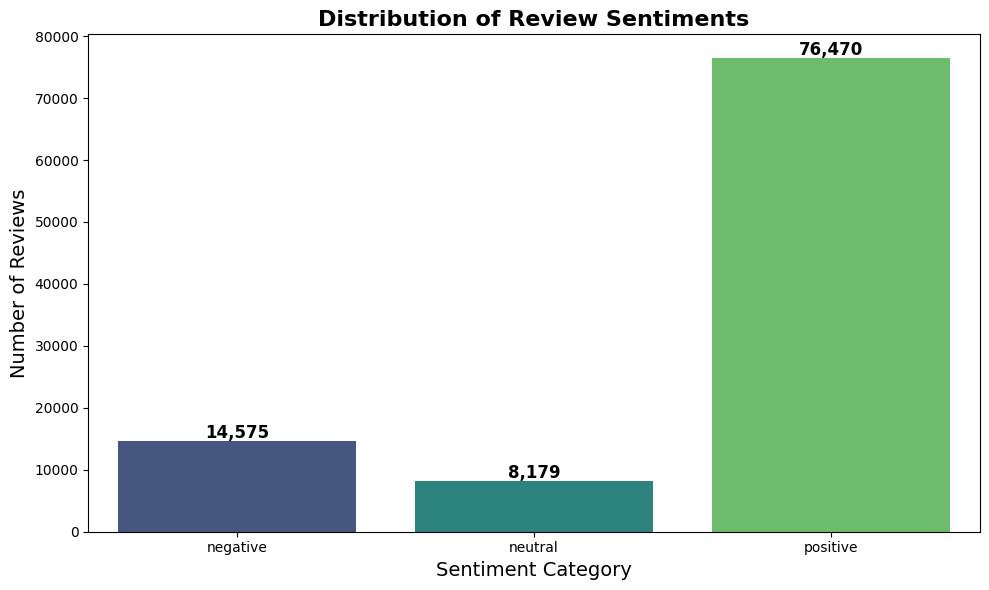

In [70]:
# Visualize the sentiment distribution - how many reviews by categories?

plt.figure(figsize=(10, 6))
sns.countplot(data=df_order_reviews, x='sentiment', palette='viridis', order=['negative', 'neutral', 'positive'])
plt.title('Distribution of Review Sentiments', fontsize=16, fontweight='bold')
plt.xlabel('Sentiment Category', fontsize=14)
plt.ylabel('Number of Reviews', fontsize=14)

# Add count labels on top of bars
for i, count in enumerate(df_order_reviews['sentiment'].value_counts().reindex(['negative', 'neutral', 'positive'])):
    plt.text(i, count + 500, f'{count:,}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

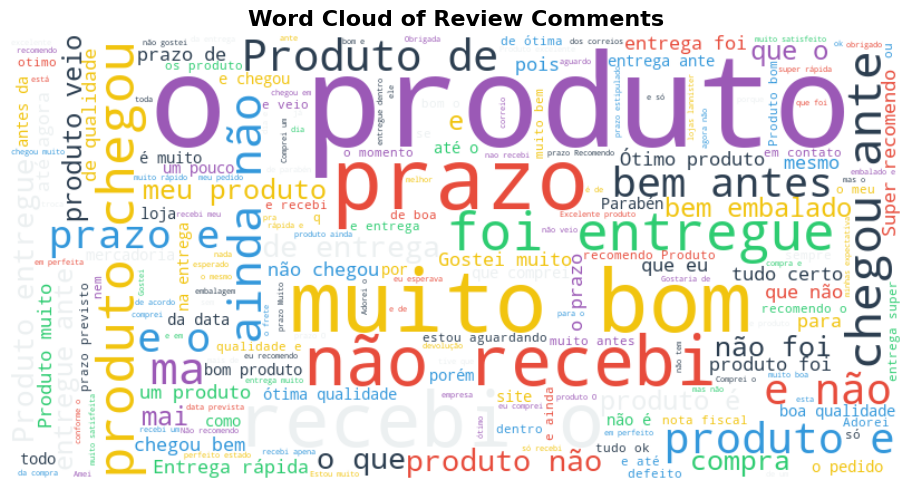

In [71]:
## Wordcloud

# Create a wordcloud on orders with negative reviews only

# Define a color function
def color_func(word, font_size, position, orientation, random_state=42, **kwargs):
    return random.choice(colors)

# Example: Word cloud from review comments
plt.figure(figsize=(10, 5))

# every order
#wordcloud = WordCloud(width=800, height=400, background_color='white', color_func=color_func).generate(' '.join(df['review_comment_message'].dropna()))

# only negative reviews
#reviews_with_negative_comments = reviews_with_comments[reviews_with_comments.review_score < 3]
wordcloud = WordCloud(width=800, height=400, background_color='white', color_func=color_func)
wordcloud.generate(' '.join(reviews_with_comments['review_comment_message'].dropna()))

plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Hide axes
plt.title('Word Cloud of Review Comments', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


## B - Text Preprocessing and conversion to numerical features

### 1 - Cleaning a small sample of the data and looking at the results

In [72]:
# create a new sample dataframe, that will be a sample of df_order_reviews
# which only have non null review_comment_messages
# which only contains review_id, review_score, review_comment_message, sentiment
# Using ALL reviews with comments for maximum model performance

df_sample = df_order_reviews[df_order_reviews['review_comment_message'].notnull()].copy()
df_sample = df_sample[['review_id', 'review_score', 'review_comment_message', 'sentiment']]

print(f"Total reviews with comments for training: {len(df_sample):,}")

Total reviews with comments for training: 40,977


In [73]:
# create a new comment_clean column which makes the text LOWER (no uppercases)

df_sample['comment_clean'] = df_sample['review_comment_message'].str.lower()

In [74]:
# remove the special characters using a simple regex function

df_sample['comment_clean'] = df_sample['comment_clean'].str.replace(r'[^a-zA-Z\s]', '', regex=True)


In [75]:
# Instead of word_tokenize, use pandas str.split()
# This breaks the string into a list of words based on spaces
df_sample['comment_clean_tokenized'] = df_sample['comment_clean'].str.split()

# Display the result to confirm it worked
df_sample.head()

,review_id,review_score,review_comment_message,sentiment,comment_clean,comment_clean_tokenized
3,e64fb393e7b32834bb789ff8bb30750e,5,Recebi bem antes do prazo estipulado.,positive,recebi bem antes do prazo estipulado,"[recebi, bem, antes, do, prazo, estipulado]"
4,f7c4243c7fe1938f181bec41a392bdeb,5,Parabéns lojas lannister adorei comprar pela I...,positive,parabns lojas lannister adorei comprar pela in...,"[parabns, lojas, lannister, adorei, comprar, p..."
9,8670d52e15e00043ae7de4c01cc2fe06,4,aparelho eficiente. no site a marca do aparelh...,positive,aparelho eficiente no site a marca do aparelho...,"[aparelho, eficiente, no, site, a, marca, do, ..."
12,4b49719c8a200003f700d3d986ea1a19,4,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",positive,mas um pouco travandopelo valor ta boa\r\n,"[mas, um, pouco, travandopelo, valor, ta, boa]"
15,3948b09f7c818e2d86c9a546758b2335,5,"Vendedor confiável, produto ok e entrega antes...",positive,vendedor confivel produto ok e entrega antes d...,"[vendedor, confivel, produto, ok, e, entrega, ..."


In [76]:
# then remove the stopwords using the portuguese library from NLTK

# Manually defining Portuguese stopwords to bypass the download error
pt_stopwords = [
    'a', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'até', 'com', 'como', 'da', 'das', 'de', 'dela', 'delas', 'dele', 'deles', 'depois', 'do', 'dos', 'e', 'é', 'ela', 'elas', 'ele', 'eles', 'em', 'entre', 'era', 'eram', 'essa', 'essas', 'esse', 'esses', 'esta', 'está', 'estamos', 'estão', 'estas', 'estava', 'estavam', 'este', 'esteja', 'estejam', 'estejamos', 'estes', 'esteve', 'estive', 'estivemos', 'estiver', 'estivera', 'estiveram', 'estiverem', 'estivermos', 'estivesse', 'estivessem', 'estivéssemos', 'estou', 'eu', 'foi', 'fomos', 'for', 'fora', 'foram', 'forem', 'formos', 'fosse', 'fossem', 'fôssemos', 'fui', 'ha', 'haja', 'hajam', 'hajamos', 'hão', 'haver', 'havia', 'haviam', 'houve', 'houvemos', 'houver', 'houvera', 'houveram', 'houverei', 'houverem', 'houveremos', 'houveria', 'houveriam', 'houvermos', 'houvesse', 'houvessem', 'houvéssemos', 'isso', 'isto', 'já', 'lhe', 'lhes', 'mais', 'mas', 'me', 'mesmo', 'meu', 'meus', 'minha', 'minhas', 'muito', 'na', 'nas', 'nem', 'no', 'nos', 'nós', 'nossa', 'nossas', 'nosso', 'nossos', 'num', 'numa', 'o', 'os', 'ou', 'para', 'pela', 'pelas', 'pelo', 'pelos', 'por', 'qual', 'quando', 'que', 'quem', 'são', 'se', 'seja', 'sejam', 'sejamos', 'sem', 'ser', 'será', 'serão', 'serei', 'seremos', 'seria', 'seriam', 'seu', 'seus', 'só', 'somos', 'sou', 'sua', 'suas', 'também', 'te', 'tem', 'tém', 'temos', 'tenha', 'tenham', 'tenhamos', 'tenho', 'terá', 'terão', 'terei', 'teremos', 'teria', 'teriam', 'teu', 'teus', 'teve', 'tinha', 'tinham', 'tive', 'tivemos', 'tiver', 'tivera', 'tiveram', 'tiverem', 'tivermos', 'tivesse', 'tivessem', 'tivéssemos', 'tu', 'tua', 'tuas', 'um', 'uma', 'você', 'vocês', 'vos'
]

# Apply the filter to remove these words from your list
df_sample['comment_clean_tokenized'] = df_sample['comment_clean_tokenized'].apply(lambda x: [word for word in x if word not in pt_stopwords])

df_sample.head()

,review_id,review_score,review_comment_message,sentiment,comment_clean,comment_clean_tokenized
3,e64fb393e7b32834bb789ff8bb30750e,5,Recebi bem antes do prazo estipulado.,positive,recebi bem antes do prazo estipulado,"[recebi, bem, antes, prazo, estipulado]"
4,f7c4243c7fe1938f181bec41a392bdeb,5,Parabéns lojas lannister adorei comprar pela I...,positive,parabns lojas lannister adorei comprar pela in...,"[parabns, lojas, lannister, adorei, comprar, i..."
9,8670d52e15e00043ae7de4c01cc2fe06,4,aparelho eficiente. no site a marca do aparelh...,positive,aparelho eficiente no site a marca do aparelho...,"[aparelho, eficiente, site, marca, aparelho, i..."
12,4b49719c8a200003f700d3d986ea1a19,4,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",positive,mas um pouco travandopelo valor ta boa\r\n,"[pouco, travandopelo, valor, ta, boa]"
15,3948b09f7c818e2d86c9a546758b2335,5,"Vendedor confiável, produto ok e entrega antes...",positive,vendedor confivel produto ok e entrega antes d...,"[vendedor, confivel, produto, ok, entrega, ant..."


In [77]:
# Use stemming to shorten the words as much as possible using another column - comment_clean_stemmed

stemmer = PorterStemmer()

from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

# Apply the stemmer to each word in the tokenized list
df_sample['comment_clean_stemmed'] = df_sample['comment_clean_tokenized'].apply(lambda x: [stemmer.stem(word) for word in x])

# Check the result
df_sample.head()

,review_id,review_score,review_comment_message,sentiment,comment_clean,comment_clean_tokenized,comment_clean_stemmed
3,e64fb393e7b32834bb789ff8bb30750e,5,Recebi bem antes do prazo estipulado.,positive,recebi bem antes do prazo estipulado,"[recebi, bem, antes, prazo, estipulado]","[recebi, bem, ant, prazo, estipulado]"
4,f7c4243c7fe1938f181bec41a392bdeb,5,Parabéns lojas lannister adorei comprar pela I...,positive,parabns lojas lannister adorei comprar pela in...,"[parabns, lojas, lannister, adorei, comprar, i...","[parabn, loja, lannist, adorei, comprar, inter..."
9,8670d52e15e00043ae7de4c01cc2fe06,4,aparelho eficiente. no site a marca do aparelh...,positive,aparelho eficiente no site a marca do aparelho...,"[aparelho, eficiente, site, marca, aparelho, i...","[aparelho, eficient, site, marca, aparelho, im..."
12,4b49719c8a200003f700d3d986ea1a19,4,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",positive,mas um pouco travandopelo valor ta boa\r\n,"[pouco, travandopelo, valor, ta, boa]","[pouco, travandopelo, valor, ta, boa]"
15,3948b09f7c818e2d86c9a546758b2335,5,"Vendedor confiável, produto ok e entrega antes...",positive,vendedor confivel produto ok e entrega antes d...,"[vendedor, confivel, produto, ok, entrega, ant...","[vendedor, confivel, produto, ok, entrega, ant..."


### 2 - Text preprocessing

In [78]:
def preprocess_text(text):
    if isinstance(text, str):
        # Convert to lowercase
        text = text.lower()
        
        # Remove special characters, numbers, and punctuation
        import re
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        
        # Tokenize the text (manual split since nltk is offline)
        tokens = text.split()
        
        # Remove stopwords (Portuguese)
        # pt_stopwords should be the list defined in your previous cell
        tokens = [word for word in tokens if word not in pt_stopwords]
        
        # Stemming
        from nltk.stem import PorterStemmer
        stemmer = PorterStemmer()
        tokens = [stemmer.stem(word) for word in tokens]
        
        # Join tokens back into a string
        clean_text = " ".join(tokens)
        
        return clean_text
    else:
        return ''

In [79]:
# Apply preprocessing to the review comments

# Apply the function to the original message column
df_sample['comment_processed'] = df_sample['review_comment_message'].apply(preprocess_text)

# Preview the transformation
df_sample[['review_comment_message', 'comment_processed']].head()

,review_comment_message,comment_processed
3,Recebi bem antes do prazo estipulado.,recebi bem ant prazo estipulado
4,Parabéns lojas lannister adorei comprar pela I...,parabn loja lannist adorei comprar internet se...
9,aparelho eficiente. no site a marca do aparelh...,aparelho eficient site marca aparelho impresso...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouco travandopelo valor ta boa
15,"Vendedor confiável, produto ok e entrega antes...",vendedor confivel produto ok entrega ant prazo


In [80]:
# Display a sample of original and processed comments

# Display original vs processed text for the first 10 rows
df_sample[['review_comment_message', 'comment_processed']].head(10)

,review_comment_message,comment_processed
3,Recebi bem antes do prazo estipulado.,recebi bem ant prazo estipulado
4,Parabéns lojas lannister adorei comprar pela I...,parabn loja lannist adorei comprar internet se...
9,aparelho eficiente. no site a marca do aparelh...,aparelho eficient site marca aparelho impresso...
12,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",pouco travandopelo valor ta boa
15,"Vendedor confiável, produto ok e entrega antes...",vendedor confivel produto ok entrega ant prazo
16,"GOSTARIA DE SABER O QUE HOUVE, SEMPRE RECEBI E...",gostaria saber sempr recebi compra agora decpcion
19,Péssimo,pssimo
22,Loja nota 10,loja nota
24,obrigado pela atençao amim dispensada,obrigado atenao amim dispensada
27,A compra foi realizada facilmente.\r\nA entreg...,compra realizada facilment entrega efetuada an...


### 3 - Final preparation steps

In [81]:
# Split the data into training and testing sets

from sklearn.model_selection import train_test_split
import time

# Note: Data is split in the next cell using sentiment labels

## C - Building a Simple Naive Bayes Model

In [82]:
X = df_sample['comment_processed']
y = df_sample['sentiment']

# Splitting 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the sizes
print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 32781
Testing set size: 8196


In [83]:
# Vectorize the text data using CountVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# Initialize the vectorizer with improved parameters
# min_df: ignore words appearing in less than 3 documents
# max_df: ignore words appearing in more than 90% of documents (common words)
# ngram_range: use unigrams and bigrams for better context
count_vectorizer = CountVectorizer(
    max_features=3000,
    min_df=3,
    max_df=0.9,
    ngram_range=(1, 2),
    lowercase=True
)

# fit_transform on training data (learns the vocabulary)
X_train_counts = count_vectorizer.fit_transform(X_train)

# transform on testing data (uses the learned vocabulary)
X_test_counts = count_vectorizer.transform(X_test)

print(f"Shape of training features: {X_train_counts.shape}")
print(f"Shape of testing features: {X_test_counts.shape}")
print(f"Vocabulary size: {len(count_vectorizer.get_feature_names_out())}")

# Some computation to find an interesting extract to look at
word_freq = X_train_counts.sum(axis=0).A1  # converting the matrix into an A1 array
word_indices = word_freq.argsort()[-10:][::-1]  # 10 most frequent words
top_feature_names = [count_vectorizer.get_feature_names_out()[i] for i in word_indices]

# creating a visualization sample with 10 most frequent words + 5 first reviews
df_bow_sample = pd.DataFrame(
    X_train_counts[:5, word_indices].toarray(),
    columns=top_feature_names
)

print("Displaying an extract of the bag-of-words matrix (5 first comments, 10 most frequent words):")
df_bow_sample

Shape of training features: (32781, 3000)
Shape of testing features: (8196, 3000)
Vocabulary size: 3000
Displaying an extract of the bag-of-words matrix (5 first comments, 10 most frequent words):


,produto,prazo,entrega,ant,chegou,recebi,bom,recomendo,ant prazo,entregu
0,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0
2,1,1,0,1,0,0,0,0,1,1
3,1,1,0,1,1,0,0,0,1,0
4,1,1,1,1,1,1,0,0,0,0


In [84]:
# Train Naive Bayes classifier with optimized parameters
from sklearn.naive_bayes import MultinomialNB

# Use alpha smoothing parameter tuning (lower alpha = less smoothing)
nb_classifier = MultinomialNB(alpha=0.1)
nb_classifier.fit(X_train_counts, y_train)
print("Naive Bayes model trained successfully!")

Naive Bayes model trained successfully!


In [85]:
y_pred = nb_classifier.predict(X_test_counts)

In [86]:

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 81.11%


In [87]:
# Display classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

# Store accuracy for later comparison
accuracy_nb = accuracy_score(y_test, y_pred)

Classification Report:

              precision    recall  f1-score   support

    negative       0.76      0.80      0.78      2151
     neutral       0.27      0.28      0.28       730
    positive       0.91      0.89      0.90      5315

    accuracy                           0.81      8196
   macro avg       0.65      0.66      0.65      8196
weighted avg       0.81      0.81      0.81      8196



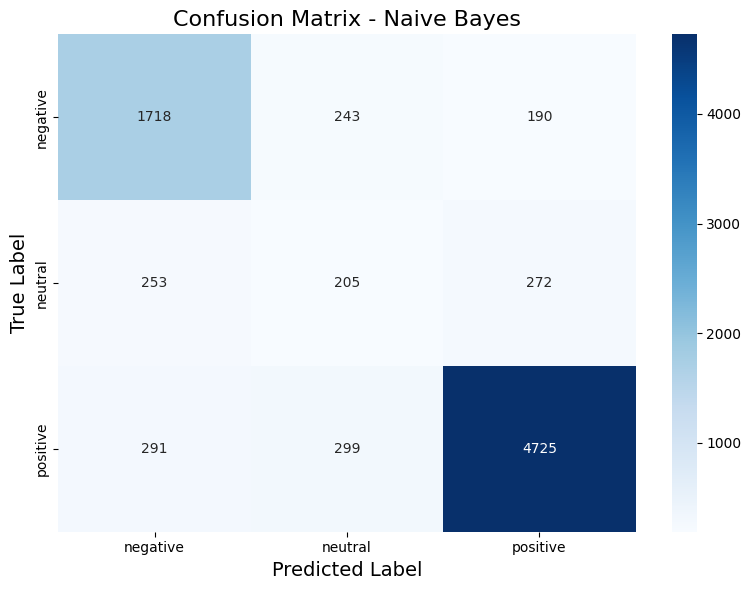

In [88]:
# Create and display confusion matrix
cm_nb = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=nb_classifier.classes_, 
            yticklabels=nb_classifier.classes_)
plt.title('Confusion Matrix - Naive Bayes', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.tight_layout()
plt.show()

## D - Building a More Advanced Model - Logistic Regression with TF-IDF

In [89]:
# Use TF-IDF Vectorizer for better feature extraction with optimized parameters
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=3,
    max_df=0.9,
    ngram_range=(1, 2),
    sublinear_tf=True,  # Apply sublinear term frequency scaling
    norm='l2'
)

# Fit and transform training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform testing data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Shape of training features: {X_train_tfidf.shape}")
print(f"Shape of testing features: {X_test_tfidf.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer.get_feature_names_out())}")

Shape of training features: (32781, 3000)
Shape of testing features: (8196, 3000)
Vocabulary size: 3000


In [90]:
# Train a Logistic Regression classifier with optimized parameters
lr_classifier = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,           # Inverse of regularization strength (lower = stronger)
    solver='lbfgs',  # Better for small datasets
    class_weight='balanced'  # Handle class imbalance
)

# Train the model
lr_classifier.fit(X_train_tfidf, y_train)
print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [91]:
# Make predictions on the test set
y_pred_lr = lr_classifier.predict(X_test_tfidf)

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.2%}")

Logistic Regression Accuracy: 76.13%


In [92]:
# Display classification report
print("Classification Report - Logistic Regression:\n")
print(classification_report(y_test, y_pred_lr))

Classification Report - Logistic Regression:

              precision    recall  f1-score   support

    negative       0.77      0.75      0.76      2151
     neutral       0.20      0.43      0.28       730
    positive       0.94      0.81      0.87      5315

    accuracy                           0.76      8196
   macro avg       0.64      0.66      0.64      8196
weighted avg       0.83      0.76      0.79      8196



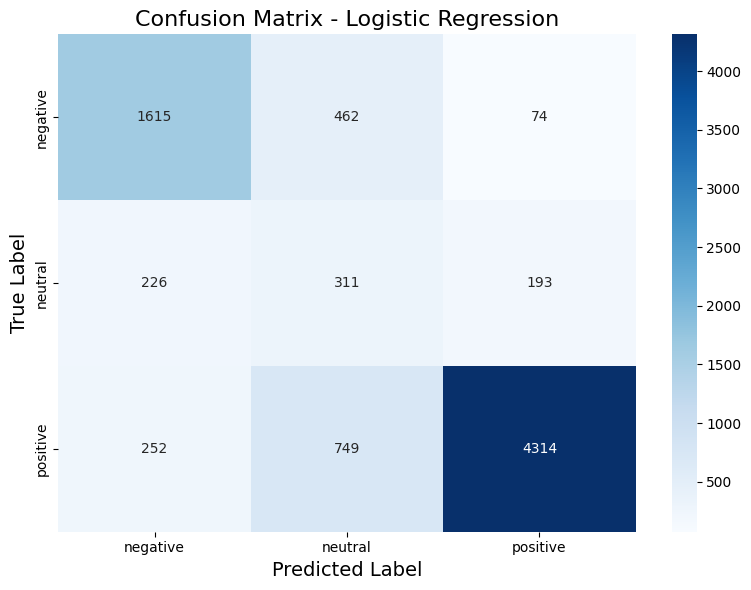

In [93]:
# Create and display confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=lr_classifier.classes_, 
            yticklabels=lr_classifier.classes_)
plt.title('Confusion Matrix - Logistic Regression', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.tight_layout()
plt.show();

In [94]:
# Get feature importance from Logistic Regression model
feature_importance = pd.DataFrame({
    'feature': tfidf_vectorizer.get_feature_names_out(),
    'importance': lr_classifier.coef_.mean(axis=0)
})

# Sort by absolute importance
feature_importance['abs_importance'] = abs(feature_importance['importance'])
feature_importance = feature_importance.sort_values('abs_importance', ascending=False)


In [95]:
# Display most important positive and negative words
print("Top 10 words associated with positive sentiment:")
positive_features = feature_importance.sort_values('importance', ascending=False).head(10)
print(positive_features[['feature', 'importance']])

print("\nTop 10 words associated with negative sentiment:")
negative_features = feature_importance.sort_values('importance', ascending=True).head(10)
print(negative_features[['feature', 'importance']])


Top 10 words associated with positive sentiment:
             feature    importance
1187        excelent  1.095420e-14
2295          pssima  9.029814e-15
42              ador  8.881784e-15
1756        ocorrido  8.363680e-15
2349   quero produto  7.401487e-15
2325   qualidad ruim  7.271961e-15
2705          talvez  7.179442e-15
759    cumpriu prazo  6.957398e-15
2129  produto acordo  6.883383e-15
2801           toner  6.846375e-15

Top 10 words associated with negative sentiment:
              feature    importance
1418         inferior -1.702342e-14
314               bom -1.502502e-14
1506            lindo -1.125026e-14
1779            otima -9.029814e-15
1850           passou -8.733754e-15
345            bonito -8.289665e-15
835             desta -7.993606e-15
2172  produto defeito -7.919591e-15
673        consumidor -7.697546e-15
1977            pouco -7.623531e-15


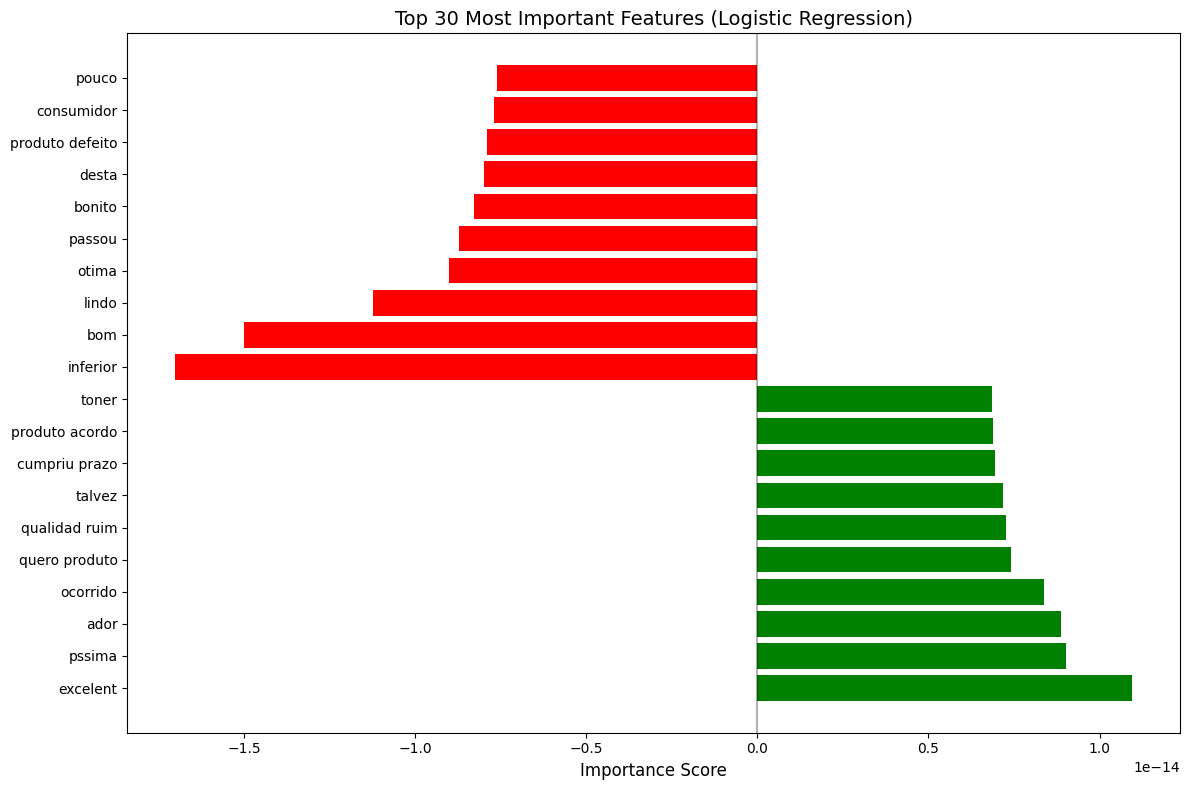

In [96]:
# Visualize top features
plt.figure(figsize=(12, 8))

top_features = pd.concat([positive_features.head(15), negative_features.head(15)])

colors = ['green' if x > 0 else 'red' for x in top_features['importance']]

plt.barh(range(len(top_features)), top_features['importance'], color=colors)
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 30 Most Important Features (Logistic Regression)', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show();


## E - Rainforest model

In [97]:
# Start a timer to understand how long the model will last
start_time = time.time()

# Create a random forest model, while limiting the number of trees to make sure it doesn't run for too long
rf_classifier = RandomForestClassifier(
    n_estimators=100,     # number of trees in the forest
    max_depth=None,       # trees can be as deep (long) as possible
    min_samples_split=2,  # minimum split number to build a node (2 trees min to build a node)
    random_state=42,
    n_jobs=-1             # use all possible resources
)

# Use the model on the X_train TF-IDF data (same than the logistic regression)
rf_classifier.fit(X_train_tfidf, y_train)

# Predictions on the test set
y_pred_rf = rf_classifier.predict(X_test_tfidf)

# Compute execution time
training_time = time.time() - start_time
print(f"Random Forest training: {training_time:.2f} seconds")


Random Forest training: 4.41 seconds


In [98]:
# Evaluate the model

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.2%}")



Random Forest Accuracy: 82.38%


In [99]:
# Display the classification report

print("Classification Report - Random Forest:\n")
print(classification_report(y_test, y_pred_rf))


Classification Report - Random Forest:

              precision    recall  f1-score   support

    negative       0.73      0.83      0.78      2151
     neutral       0.32      0.03      0.06       730
    positive       0.87      0.93      0.90      5315

    accuracy                           0.82      8196
   macro avg       0.64      0.60      0.58      8196
weighted avg       0.79      0.82      0.79      8196



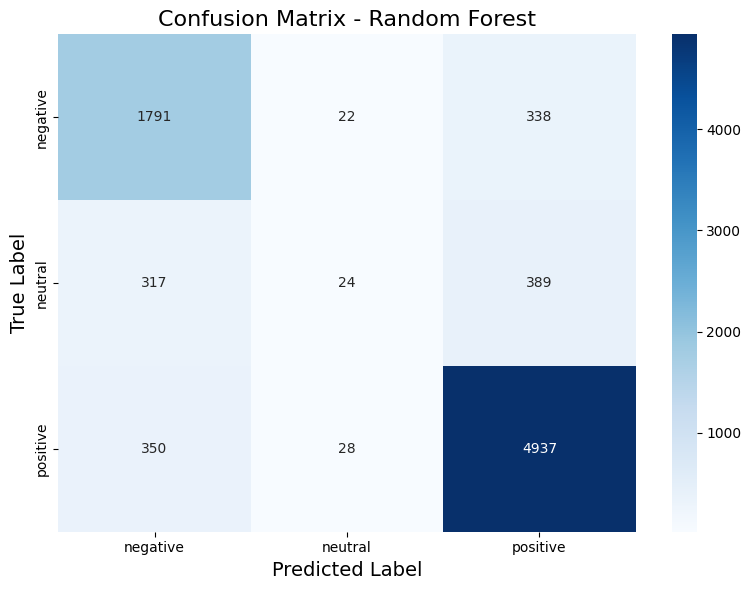

In [100]:
# Create and display the confusion matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', 
            xticklabels=rf_classifier.classes_, 
            yticklabels=rf_classifier.classes_)
plt.title('Confusion Matrix - Random Forest', fontsize=16)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.tight_layout()
plt.show()


In [101]:
# get the feature importance of the Random Forest model

rf_feature_importance = pd.DataFrame({
    'feature': tfidf_vectorizer.get_feature_names_out(),
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 most important features in Random Forest:")
print(rf_feature_importance.head(10))


Top 10 most important features in Random Forest:
        feature  importance
2390     recebi    0.029193
586     comprei    0.022695
2127    produto    0.017716
141         ant    0.017462
1997      prazo    0.015477
314         bom    0.015367
2893       veio    0.013864
2442  recomendo    0.012361
147   ant prazo    0.010930
1680        nao    0.010847


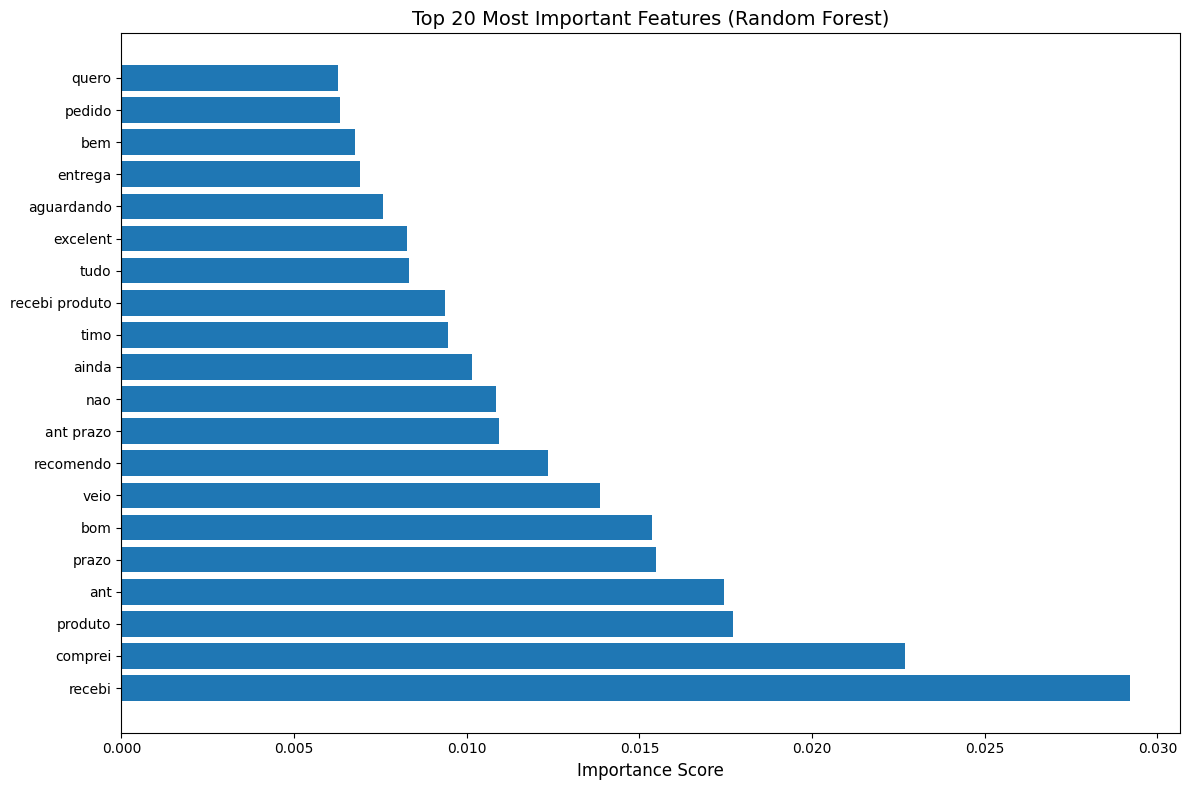

In [102]:
# Visualize the most important features

plt.figure(figsize=(12, 8))
top_rf_features = rf_feature_importance.head(20)
plt.barh(range(len(top_rf_features)), top_rf_features['importance'])
plt.yticks(range(len(top_rf_features)), top_rf_features['feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 20 Most Important Features (Random Forest)', fontsize=14)
plt.tight_layout()
plt.show()


## F - Model comparison

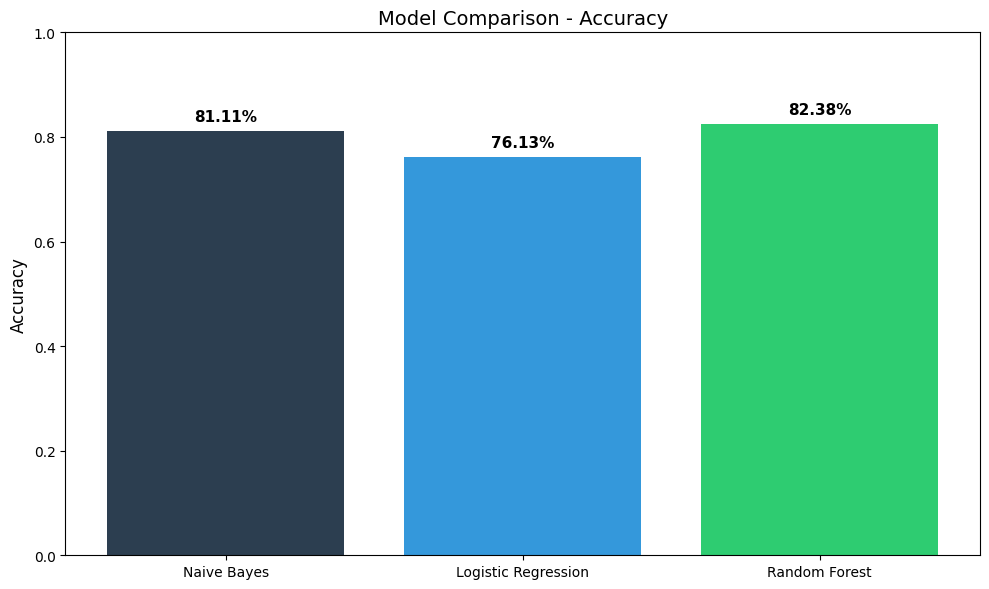

In [103]:

# Compare the performances of the 3 models
models = ['Naive Bayes', 'Logistic Regression', 'Random Forest']
accuracies = [accuracy_nb, accuracy_lr, accuracy_rf]

plt.figure(figsize=(10, 6))
plt.bar(models, accuracies, color=['#2C3E50', '#3498DB', '#2ECC71'])
plt.ylabel('Accuracy', fontsize=12)
plt.title('Model Comparison - Accuracy', fontsize=14)
plt.ylim([0, 1])
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f'{v:.2%}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


<Figure size 1000x600 with 0 Axes>

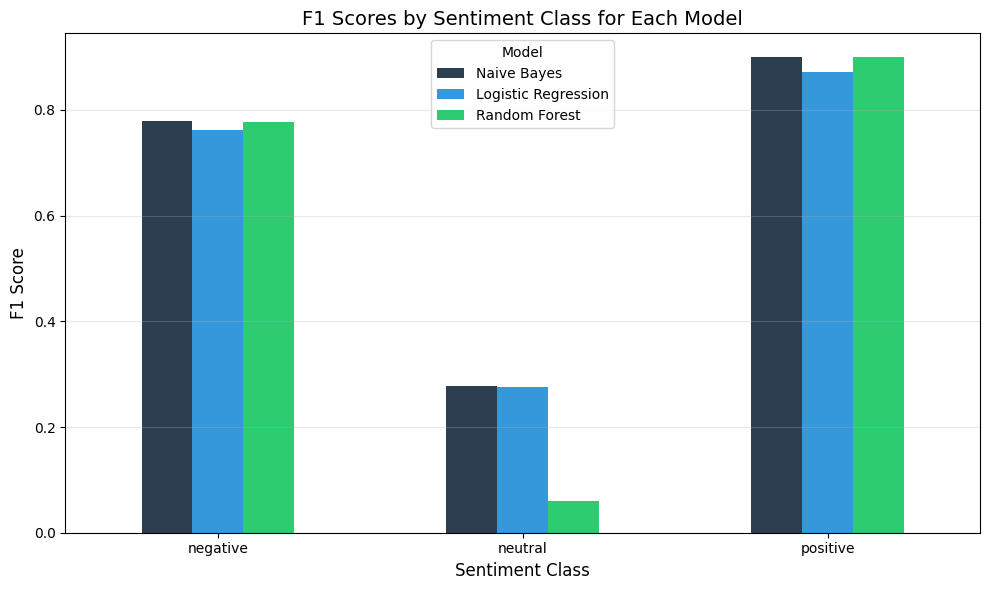

In [104]:
# Compute the F1 score by class (f1_nb, f1_lr, f1_rf)

f1_nb = f1_score(y_test, y_pred, average=None)
f1_lr = f1_score(y_test, y_pred_lr, average=None)
f1_rf = f1_score(y_test, y_pred_rf, average=None)

# Create a dataframe for the visualization
f1_df = pd.DataFrame({
    'Naive Bayes': f1_nb,
    'Logistic Regression': f1_lr,
    'Random Forest': f1_rf
}, index=rf_classifier.classes_)

# Visualize F1 scores by classes

plt.figure(figsize=(10, 6))
f1_df.plot(kind='bar', figsize=(10, 6), color=['#2C3E50', '#3498DB', '#2ECC71'])
plt.ylabel('F1 Score', fontsize=12)
plt.xlabel('Sentiment Class', fontsize=12)
plt.title('F1 Scores by Sentiment Class for Each Model', fontsize=14)
plt.legend(title='Model', fontsize=10)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## G - Example use case: predicting new comments

In [105]:
# Create a function to predict sentiment for new reviews
def predict_sentiment(review_text, vectorizer, model):
    # Preprocess the review
    processed_review = preprocess_text(review_text)
    # Vectorize the review
    review_vector = vectorizer.transform([processed_review])
    # Predict the sentiment
    sentiment = model.predict(review_vector)[0]
    # Get prediction probabilities
    proba = model.predict_proba(review_vector)[0]
    # Return the sentiment and confidence
    return sentiment, proba


In [106]:
# Example reviews to test
example_reviews = [
    "O produto é excelente, superou minhas expectativas!",  # Positive
    "Entrega foi feita no prazo, mas o produto não é tão bom quanto esperava.",  # Neutral
    "Péssimo produto, chegou com defeito e o atendimento ao cliente foi horrível."  # Negative
]

# Predict sentiment for example reviews
print("Predicting sentiment for example reviews:")
for i, review in enumerate(example_reviews):
    sentiment, proba = predict_sentiment(review, tfidf_vectorizer, lr_classifier)
    print(f"\nExample {i+1}: {review}")
    print(f"Predicted sentiment: {sentiment}")
    print(f"Confidence: {max(proba):.2f}")
    print(f"Probabilities: {dict(zip(lr_classifier.classes_, proba))}")
    

Predicting sentiment for example reviews:

Example 1: O produto é excelente, superou minhas expectativas!
Predicted sentiment: positive
Confidence: 0.99
Probabilities: {'negative': 0.005055270729927529, 'neutral': 0.00970234888731423, 'positive': 0.9852423803827582}

Example 2: Entrega foi feita no prazo, mas o produto não é tão bom quanto esperava.
Predicted sentiment: neutral
Confidence: 0.89
Probabilities: {'negative': 0.04249060434647912, 'neutral': 0.8878231057087235, 'positive': 0.0696862899447975}

Example 3: Péssimo produto, chegou com defeito e o atendimento ao cliente foi horrível.
Predicted sentiment: negative
Confidence: 0.88
Probabilities: {'negative': 0.8761545282263321, 'neutral': 0.08601141766541681, 'positive': 0.03783405410825107}


# II - Delivery prediction (bonus)

## A - Data preparation

In [107]:
# We'll use the merged dataframe from previous parts
# Force reload to ensure sellers data is included
# Load required datasets
df_orders = pd.read_csv(raw_path + 'olist_orders_dataset.csv')
df_customers = pd.read_csv(raw_path + 'olist_customers_dataset.csv')
df_order_items = pd.read_csv(raw_path + 'olist_order_items_dataset.csv')
df_products = pd.read_csv(raw_path + 'olist_products_dataset.csv')
df_sellers = pd.read_csv(raw_path + 'olist_sellers_dataset.csv')

# Merge datasets
df = df_orders.merge(df_customers, on='customer_id')
df = df.merge(df_order_items, on='order_id')
df = df.merge(df_products, on='product_id')
df = df.merge(df_sellers, on='seller_id')

df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,59296,...,59.0,468.0,3.0,450.0,30.0,10.0,20.0,31842,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,38.0,316.0,4.0,250.0,51.0,15.0,15.0,8752,mogi das cruzes,SP


In [108]:
# Convert date columns to datetime
date_columns = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_carrier_date', 'order_delivered_customer_date',
                'order_estimated_delivery_date']

for col in date_columns:
    df[col] = pd.to_datetime(df[col])


# Calculate delivery time in days
df['actual_delivery_time'] = (df['order_delivered_customer_date'] - 
                             df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

# Calculate if the delivery was delayed (1) or not (0)
df['estimated_delivery_time'] = (df['order_estimated_delivery_date'] - 
                                df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)
df['is_delayed'] = (df['actual_delivery_time'] > df['estimated_delivery_time']).astype(int)

# Calculate time to carrier in days
df['time_to_carrier'] = (df['order_delivered_carrier_date'] - 
                        df['order_purchase_timestamp']).dt.total_seconds() / (24 * 3600)

# Filter out rows with missing delivery dates (canceled orders, etc.)
delivery_df = df.dropna(subset=['order_delivered_customer_date', 'order_delivered_carrier_date'])

delivery_df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,actual_delivery_time,estimated_delivery_time,is_delayed,time_to_carrier
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,19.0,8.0,13.0,9350,maua,SP,8.436574,15.544063,0,2.373924
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,19.0,13.0,19.0,31570,belo horizonte,SP,13.782037,19.137766,0,1.742627
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,24.0,19.0,21.0,14840,guariba,SP,9.394213,26.639711,0,0.216100
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,...,30.0,10.0,20.0,31842,belo horizonte,MG,13.208750,26.188819,0,3.758252
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,...,51.0,15.0,15.0,8752,mogi das cruzes,SP,2.873877,12.112049,0,0.936053


/tmp/ipykernel_8088/1813984735.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_delayed', data=delivery_df, palette='viridis')


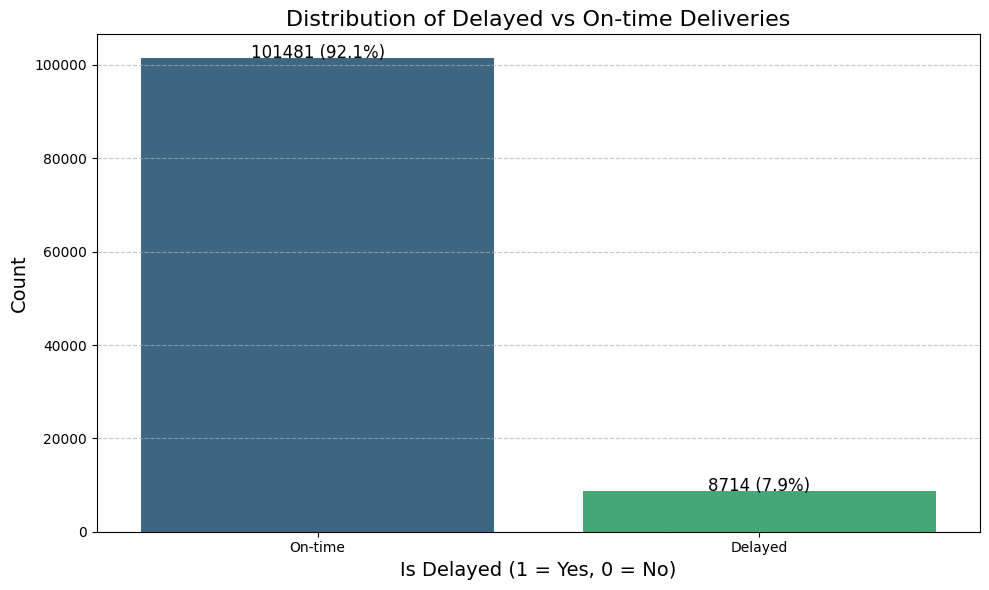

In [109]:
# Visualize the distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='is_delayed', data=delivery_df, palette='viridis')
plt.title('Distribution of Delayed vs On-time Deliveries', fontsize=16)
plt.xlabel('Is Delayed (1 = Yes, 0 = No)', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks([0, 1], ['On-time', 'Delayed'])
for i, count in enumerate(delivery_df['is_delayed'].value_counts()):
    plt.text(i, count + 100, f"{count} ({count/len(delivery_df):.1%})", 
             ha='center', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


## B - Feature Engineering

In [110]:

model_df = delivery_df.copy()

# Extract temporal features
model_df['purchase_hour'] = model_df['order_purchase_timestamp'].dt.hour
model_df['purchase_day'] = model_df['order_purchase_timestamp'].dt.day
model_df['purchase_month'] = model_df['order_purchase_timestamp'].dt.month
model_df['purchase_year'] = model_df['order_purchase_timestamp'].dt.year
model_df['purchase_dayofweek'] = model_df['order_purchase_timestamp'].dt.dayofweek
model_df['purchase_weekend'] = (model_df['purchase_dayofweek'] >= 5).astype(int)

# Calculate distance between customer and seller (using zip code prefix as a proxy)
model_df['zip_distance'] = abs(model_df['customer_zip_code_prefix'] - model_df['seller_zip_code_prefix'])

# Calculate price per weight
model_df['price_per_weight'] = model_df['price'] / model_df['product_weight_g'].replace(0, 0.1)

# Create product volume feature
model_df['product_volume'] = (model_df['product_length_cm'] * 
                             model_df['product_height_cm'] * 
                             model_df['product_width_cm'])

# Handle infinite values
model_df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Display the first few rows of the engineered features
print("Sample of engineered features:")
model_df[['purchase_hour', 'purchase_day', 'purchase_month', 'purchase_year', 
                'purchase_dayofweek', 'purchase_weekend', 'zip_distance', 
                'price_per_weight', 'product_volume']].head()

Sample of engineered features:


,purchase_hour,purchase_day,purchase_month,purchase_year,purchase_dayofweek,purchase_weekend,zip_distance,price_per_weight,product_volume
0,10,2,10,2017,0,0,6201,0.059980,1976.0
1,20,24,7,2018,1,0,16243,0.296750,4693.0
2,8,8,8,2018,2,0,60425,0.380714,9576.0
3,19,18,11,2017,5,1,27454,0.100000,6000.0
4,21,13,2,2018,1,0,443,0.079600,11475.0


## C - Exploratory Data Analysis for Feature Selection

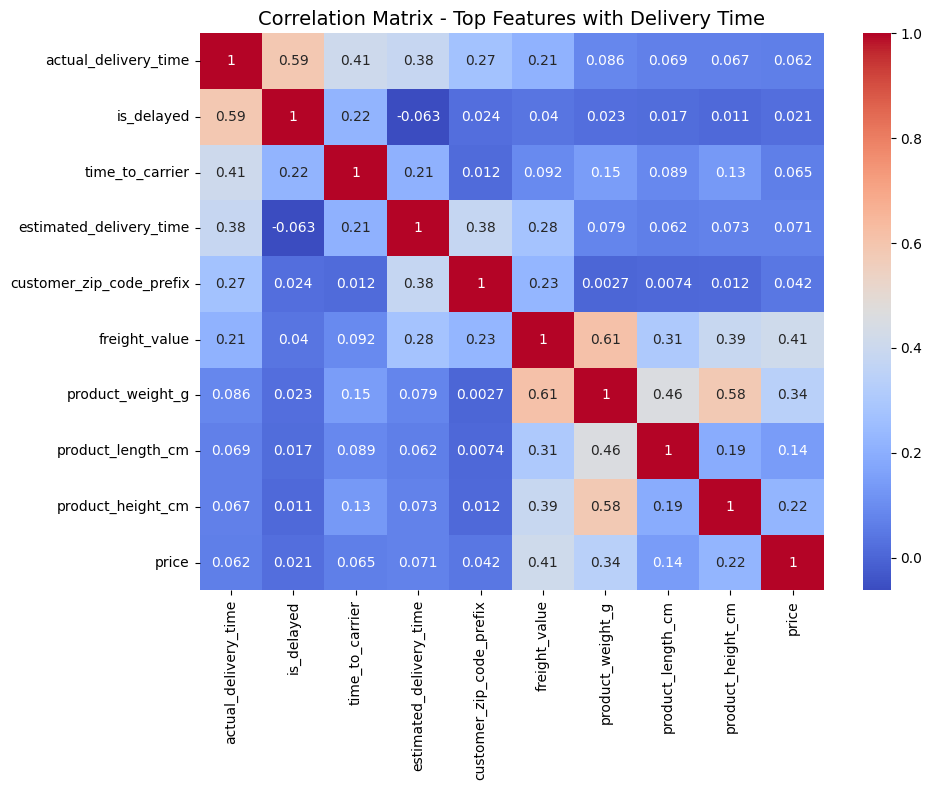

Top correlations with actual delivery time:
actual_delivery_time        1.000000
is_delayed                  0.585507
time_to_carrier             0.408069
estimated_delivery_time     0.382927
customer_zip_code_prefix    0.273148
freight_value               0.214717
product_weight_g            0.085677
product_length_cm           0.068806
product_height_cm           0.066869
price                       0.062383
Name: actual_delivery_time, dtype: float64


In [111]:
# Analyze correlation between features and delivery time with a correlation matrix

# Calculate correlation with actual delivery time
numeric_columns = delivery_df.select_dtypes(include=[np.number]).columns
correlations = delivery_df[numeric_columns].corr()['actual_delivery_time'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.heatmap(delivery_df[list(correlations.index[:10])].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix - Top Features with Delivery Time', fontsize=14)
plt.tight_layout()
plt.show()

print("Top correlations with actual delivery time:")
print(correlations.head(10))

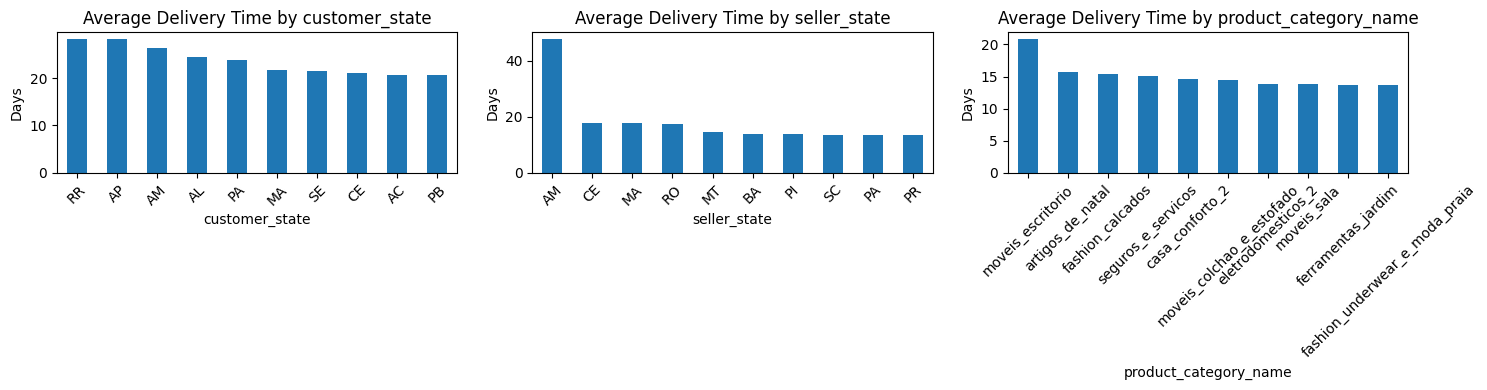

In [112]:
# Analyze categorical features
categorical_features = ['customer_state', 'seller_state', 'product_category_name']

# compute the average delivery time for each of the categorical feature with a bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, feature in enumerate(categorical_features):
    if feature in delivery_df.columns:
        avg_delivery = delivery_df.groupby(feature)['actual_delivery_time'].mean().sort_values(ascending=False)
        avg_delivery.head(10).plot(kind='bar', ax=axes[idx])
        axes[idx].set_title(f'Average Delivery Time by {feature}', fontsize=12)
        axes[idx].set_ylabel('Days', fontsize=10)
        axes[idx].set_xlabel(feature, fontsize=10)
        axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## D - Feature Selection

In [113]:
# Select features based on correlation analysis and domain knowledge
selected_numeric_features = ['freight_value', 'price', 'product_weight_g', 
                            'product_volume', 'zip_distance', 'time_to_carrier',
                            'purchase_month', 'purchase_dayofweek']

# Categorical features
selected_categorical_features = ['customer_state', 'seller_state']

# Remove rows with missing values in selected features
model_df_clean = model_df.dropna(subset=selected_numeric_features + selected_categorical_features)
print(f"Rows after removing NaN: {len(model_df_clean)} (removed {len(model_df) - len(model_df_clean)} rows)")

Rows after removing NaN: 110177 (removed 18 rows)


In [114]:
# Prepare feature and target variables
from sklearn.preprocessing import LabelEncoder

X_numeric = model_df_clean[selected_numeric_features].copy()
X_categorical = model_df_clean[selected_categorical_features].copy()

# Encode categorical features
le_dict = {}
for col in selected_categorical_features:
    le = LabelEncoder()
    X_categorical[col] = le.fit_transform(X_categorical[col].astype(str))
    le_dict[col] = le

X_combined = pd.concat([X_numeric, X_categorical], axis=1)

# For regression task (predicting delivery time)
y_regression = model_df_clean['actual_delivery_time']

# Split the data
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X_combined, y_regression, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (88141, 10)
Testing set shape: (22036, 10)


## E - Building the Regression Model (Predicting Delivery Time)

In [115]:
# Define preprocessing for numeric features
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

scaler = StandardScaler()

In [116]:
# Create a Linear Regression Pipeline

# Create a pipeline with scaler and linear regression
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Train the model
pipeline_lr.fit(X_train, y_reg_train)

# Make predictions
y_pred_lr = pipeline_lr.predict(X_test)

# Evaluate the model
mae_lr = mean_absolute_error(y_reg_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_reg_test, y_pred_lr))
r2_lr = r2_score(y_reg_test, y_pred_lr)

print(f"Linear Regression - MAE: {mae_lr:.2f} days")
print(f"Linear Regression - RMSE: {rmse_lr:.2f} days")
print(f"Linear Regression - R²: {r2_lr:.4f}")

Linear Regression - MAE: 4.84 days
Linear Regression - RMSE: 7.67 days
Linear Regression - R²: 0.3058


In [117]:
# Make predictions based on your linear regression
y_pred_lr = pipeline_lr.predict(X_test)

# Note: Model has already been evaluated above with MAE, RMSE, and R² scores




the R² should be about 0.40, which is not a good number. Can you do better with a Random Forest model, or any other model? 

Objective is to get a R² > 0.45!

## F - Building a Random Forest model

In [118]:
from sklearn.ensemble import RandomForestRegressor

# Create and train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_reg_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_reg_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_reg_test, y_pred_rf))
r2_rf = r2_score(y_reg_test, y_pred_rf)

print(f"Random Forest - MAE: {mae_rf:.2f} days")
print(f"Random Forest - RMSE: {rmse_rf:.2f} days")
print(f"Random Forest - R²: {r2_rf:.4f}")

# Feature importance
feature_importance_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance_rf.head(10))

Random Forest - MAE: 3.97 days
Random Forest - RMSE: 6.76 days
Random Forest - R²: 0.4620

Top 10 Most Important Features:
              feature  importance
5     time_to_carrier    0.299953
8      customer_state    0.208122
4        zip_distance    0.109478
0       freight_value    0.097670
6      purchase_month    0.086129
1               price    0.059107
3      product_volume    0.054196
2    product_weight_g    0.044313
7  purchase_dayofweek    0.021742
9        seller_state    0.019290


### G - Building a K-Nearest Neighbors model

In [119]:
from sklearn.neighbors import KNeighborsRegressor

# Create and train KNN model
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X_train, y_reg_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

# Evaluate the model
mae_knn = mean_absolute_error(y_reg_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_reg_test, y_pred_knn))
r2_knn = r2_score(y_reg_test, y_pred_knn)

print(f"K-Nearest Neighbors - MAE: {mae_knn:.2f} days")
print(f"K-Nearest Neighbors - RMSE: {rmse_knn:.2f} days")
print(f"K-Nearest Neighbors - R²: {r2_knn:.4f}")

# Compare all three models
print("\n=== Model Comparison ===")
models_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'K-Nearest Neighbors'],
    'MAE': [mae_lr, mae_rf, mae_knn],
    'RMSE': [rmse_lr, rmse_rf, rmse_knn],
    'R²': [r2_lr, r2_rf, r2_knn]
})

print(models_comparison)
print(f"\nBest Model: {models_comparison.loc[models_comparison['R²'].idxmax(), 'Model']} (R² = {models_comparison['R²'].max():.4f})")

K-Nearest Neighbors - MAE: 5.95 days
K-Nearest Neighbors - RMSE: 9.09 days
K-Nearest Neighbors - R²: 0.0249

=== Model Comparison ===
                 Model       MAE      RMSE        R²
0    Linear Regression  4.836318  7.674057  0.305793
1        Random Forest  3.970596  6.755596  0.462020
2  K-Nearest Neighbors  5.947071  9.094878  0.024938

Best Model: Random Forest (R² = 0.4620)
